# 03_modeling_baseline_cleaned

Version allégée du notebook de modélisation pour le **Projet 12**.

## Objectifs de cette version
- conserver une **trace claire** des choix méthodologiques utiles ;
- retirer du corps principal les blocs devenus trop lourds :
  - feature engineering non retenu,
  - analyses d'outliers / winsorisation non retenues,
  - benchmarks intermédiaires redondants ;
- **conserver** le modèle général historique comme **baseline** ;
- ajouter un **nouveau modèle 1 culture-spécifique** avec `Crop`, mieux aligné avec le besoin métier et les futurs endpoints de l'API ;
- exporter les modèles sous des noms explicites :
  - `model_1_general.*`
  - `model_1_crop.*`

## Ce qui a été retiré du corps principal
- le bloc complet de feature engineering ;
- le bloc de vérification/winsorisation des outliers ;
- les duplications de fonctions et certains benchmarks intermédiaires.

## Ce qui reste dans le notebook principal
1. préparation et helpers ;
2. rappel synthétique sur l'enrichissement externe ;
3. benchmark métier léger sur échantillon ;
4. baseline générale sur full dataset ;
5. nouveau modèle culture-spécifique sur full dataset ;
6. export des artefacts utiles pour l'API.

In [50]:
from pathlib import Path
import sys
import json
import joblib

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from catboost import CatBoostRegressor
from sklearn.preprocessing import PolynomialFeatures

from project_paths import PROCESSED_DIR

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

SEED = 42
SAMPLE_SIZE = 200_000

ARTIFACTS_DIR = ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

OUT_DIR = ROOT / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("Artifacts:", ARTIFACTS_DIR)

ROOT: C:\Users\thoma\Documents\Openclassroom\Projet-12
PROCESSED_DIR: C:\Users\thoma\Documents\Openclassroom\Projet-12\data\processed
Artifacts: C:\Users\thoma\Documents\Openclassroom\Projet-12\artifacts


In [51]:
MLFLOW_DB_PATH = ROOT / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{MLFLOW_DB_PATH.as_posix()}")
mlflow.set_experiment("projet-12-model-1")

print("MLflow version :", mlflow.__version__)
print("Tracking URI :", mlflow.get_tracking_uri())

MLflow version : 3.10.1
Tracking URI : sqlite:///C:/Users/thoma/Documents/Openclassroom/Projet-12/mlflow.db


## Chargement des données
On conserve :
- `crop_aux_clean.csv` comme dataset principal du modèle 1 ;
- `crop_aux_enriched.csv` uniquement pour un **rappel synthétique** sur l'enrichissement externe.

In [52]:
crop_aux = pd.read_csv(PROCESSED_DIR / "crop_aux_clean.csv")
crop_aux_enriched = pd.read_csv(PROCESSED_DIR / "crop_aux_enriched.csv")

print("crop_aux :", crop_aux.shape)
print("crop_aux_enriched :", crop_aux_enriched.shape)

target_col = "Yield_tons_per_hectare"

assert (crop_aux[target_col] >= 0).all(), "La cible contient encore des valeurs négatives."
display(crop_aux[[target_col]].describe().T)

crop_aux : (999769, 10)
crop_aux_enriched : (999769, 23)


,count,mean,std,min,25%,50%,75%,max
Yield_tons_per_hectare,999769.0,4.650592,1.695166,0.000411,3.418669,4.652333,5.879576,9.963372


In [53]:
crop_aux_sample = crop_aux.sample(n=min(SAMPLE_SIZE, len(crop_aux)), random_state=SEED).copy()
crop_aux_enriched_sample = crop_aux_enriched.sample(n=min(SAMPLE_SIZE, len(crop_aux_enriched)), random_state=SEED).copy()

print("Sample base :", crop_aux_sample.shape)
print("Sample enriched :", crop_aux_enriched_sample.shape)

Sample base : (200000, 10)
Sample enriched : (200000, 23)


In [54]:
crop_aux_enriched.head()

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare,...,ext_mean_pesticides_by_crop,ext_n_obs_by_crop,ext_mean_yield_by_crop,rainfall_gap_vs_crop_profile,temp_gap_vs_crop_profile,crop_profile_pc1,crop_profile_pc2,Crop_std_y,crop_external_pc1,crop_external_pc2
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341,...,16443.811451,1502.0,37541.646471,-228.423922,-2.771965,1.316644,-0.820577,Rice,1.438031,1.064397
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573,...,20043.068696,1242.0,16563.747987,-148.959756,-1.581653,1.111131,1.571387,Soybean,1.604274,-1.392803
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251,...,15075.697000,1810.0,30782.991713,-175.815301,15.226447,-2.523449,1.031676,Wheat,-2.015868,-1.052009


## Helpers
Fonctions factorisées pour éviter les duplications du notebook précédent.

In [55]:
def split_feature_types(df: pd.DataFrame):
    bool_features = df.select_dtypes(include="bool").columns.tolist()
    numeric_features = df.select_dtypes(include=np.number).columns.tolist()
    numeric_features = numeric_features + [c for c in bool_features if c not in numeric_features]
    categorical_features = [c for c in df.columns if c not in numeric_features]
    return numeric_features, categorical_features


def build_preprocessor(numeric_features, categorical_features):
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    return ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features),
    ])


def evaluate_regression(y_true, y_pred, dataset_name: str, model_name: str) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))

    return {
        "dataset": dataset_name,
        "model": model_name,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
    }


def make_pipeline(model, X: pd.DataFrame):
    numeric_features, categorical_features = split_feature_types(X)
    preprocessor = build_preprocessor(numeric_features, categorical_features)
    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])


def benchmark_models(
    X_train,
    X_test,
    y_train,
    y_test,
    models: dict,
    dataset_name: str,
    stage: str,
):
    results = []

    for model_name, model in models.items():
        pipe = make_pipeline(model, X_train)

        with mlflow.start_run(run_name=f"{dataset_name}__{model_name}"):
            mlflow.set_tags({
                "project": "Projet-12",
                "notebook": "03_modeling_baseline_cleaned",
                "stage": stage,
                "dataset_name": dataset_name,
                "model_name": model_name,
            })
            mlflow.log_param("dataset_name", dataset_name)
            mlflow.log_param("model_name", model_name)
            mlflow.log_param("stage", stage)
            mlflow.log_param("n_train_rows", len(X_train))
            mlflow.log_param("n_test_rows", len(X_test))
            mlflow.log_param("feature_names", ",".join(X_train.columns.tolist()))

            if hasattr(model, "get_params"):
                safe_params = {}
                for k, v in model.get_params().items():
                    if isinstance(v, (str, int, float, bool, np.integer, np.floating)):
                        safe_params[k] = v
                mlflow.log_params(safe_params)

            pipe.fit(X_train, y_train)
            preds = pipe.predict(X_test)

            result = evaluate_regression(y_test, preds, dataset_name, model_name)
            mlflow.log_metrics({
                "rmse": result["rmse"],
                "mae": result["mae"],
                "r2": result["r2"],
            })

            results.append(result)

    return pd.DataFrame(results).sort_values("rmse").reset_index(drop=True)


def cross_validate_pipeline(pipe, X, y, run_name: str, stage: str, extra_params: dict | None = None):
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    scoring = {
        "rmse": "neg_root_mean_squared_error",
        "mae": "neg_mean_absolute_error",
        "r2": "r2",
    }

    scores = cross_validate(
        pipe,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False,
    )

    summary = {
        "rmse_mean": float(-scores["test_rmse"].mean()),
        "rmse_std": float((-scores["test_rmse"]).std()),
        "mae_mean": float(-scores["test_mae"].mean()),
        "mae_std": float((-scores["test_mae"]).std()),
        "r2_mean": float(scores["test_r2"].mean()),
        "r2_std": float(scores["test_r2"].std()),
    }

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({
            "project": "Projet-12",
            "notebook": "03_modeling_baseline_cleaned",
            "stage": stage,
        })
        if extra_params:
            mlflow.log_params(extra_params)
        mlflow.log_metrics(summary)

    return summary


def holdout_metrics(pipe, X_train, X_test, y_train, y_test, dataset_name: str, model_name: str):
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    return evaluate_regression(y_test, preds, dataset_name, model_name), preds


def export_model_with_meta(pipe, X_ref, meta: dict, model_path: Path, meta_path: Path, run_name: str):
    pipe.fit(X_ref, meta["target_series"])
    signature = infer_signature(X_ref, pipe.predict(X_ref.head(100)))

    joblib.dump(pipe, model_path)

    meta_to_save = meta.copy()
    meta_to_save.pop("target_series", None)
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(meta_to_save, f, indent=2, ensure_ascii=False)

    with mlflow.start_run(run_name=run_name):
        mlflow.set_tags({
            "project": "Projet-12",
            "notebook": "03_modeling_baseline_cleaned",
            "stage": "export_model",
            "export_name": model_path.name,
        })
        params_to_log = {}
        for k, v in meta_to_save.items():
            if isinstance(v, (str, int, float, bool)):
                params_to_log[k] = v
        if params_to_log:
            mlflow.log_params(params_to_log)

        if "reference_metrics" in meta_to_save:
            for k, v in meta_to_save["reference_metrics"].items():
                if isinstance(v, (int, float)):
                    mlflow.log_metric(k, float(v))

        mlflow.sklearn.log_model(pipe, artifact_path="model", signature=signature)
        mlflow.log_artifact(str(meta_path))

## 1. Rappel synthétique : l'enrichissement externe n'est pas retenu
On conserve ici une comparaison simple **Ridge base vs Ridge enrichi** sur échantillon, uniquement pour garder une trace courte de la décision.

In [56]:
base_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
    "Days_to_Harvest",
]

enriched_features = [
    "Region",
    "Soil_Type",
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "Weather_Condition",
    "Days_to_Harvest",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
]

X_base_sample = crop_aux_sample[base_features].copy()
y_base_sample = crop_aux_sample[target_col].copy()

X_enriched_sample = crop_aux_enriched_sample[enriched_features].copy()
y_enriched_sample = crop_aux_enriched_sample[target_col].copy()

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_base_sample, y_base_sample, test_size=0.2, random_state=SEED
)
Xe_train, Xe_test, ye_train, ye_test = train_test_split(
    X_enriched_sample, y_enriched_sample, test_size=0.2, random_state=SEED
)

ridge_base_pipe = make_pipeline(Ridge(alpha=1.0), Xb_train)
ridge_enriched_pipe = make_pipeline(Ridge(alpha=1.0), Xe_train)

ridge_base_result, _ = holdout_metrics(
    ridge_base_pipe, Xb_train, Xb_test, yb_train, yb_test,
    dataset_name="sample_base_reference",
    model_name="ridge",
)
ridge_enriched_result, _ = holdout_metrics(
    ridge_enriched_pipe, Xe_train, Xe_test, ye_train, ye_test,
    dataset_name="sample_enriched_reference",
    model_name="ridge",
)

enrichment_check = pd.DataFrame([ridge_base_result, ridge_enriched_result]).sort_values("rmse")
display(enrichment_check)

with mlflow.start_run(run_name="sample_enrichment_check_ridge"):
    mlflow.set_tags({
        "project": "Projet-12",
        "notebook": "03_modeling_baseline_cleaned",
        "stage": "enrichment_check",
    })
    for _, row in enrichment_check.iterrows():
        prefix = row["dataset"]
        mlflow.log_metric(f"{prefix}_rmse", float(row["rmse"]))
        mlflow.log_metric(f"{prefix}_mae", float(row["mae"]))
        mlflow.log_metric(f"{prefix}_r2", float(row["r2"]))

,dataset,model,rmse,mae,r2
1,sample_enriched_reference,ridge,0.496710,0.396081,0.913943
0,sample_base_reference,ridge,0.496723,0.396089,0.913939


## 2. Baseline générale conservée
On conserve le modèle historique le plus simple comme **baseline générale**.
Il n'est plus considéré comme le modèle métier principal pour l'API, mais il reste utile :
- comme référence ;
- comme trace méthodologique ;
- comme point de comparaison futur.

In [57]:
general_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
]

X_general_sample = crop_aux_sample[general_features].copy()
y_general_sample = crop_aux_sample[target_col].copy()

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_general_sample, y_general_sample, test_size=0.2, random_state=SEED
)

general_models = {
    "dummy_mean": DummyRegressor(strategy="mean"),
    "ridge": Ridge(alpha=0.1),
    "catboost": CatBoostRegressor(
        iterations=300,
        depth=6,
        learning_rate=0.05,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_state=SEED,
        verbose=0,
        allow_writing_files=False,
        thread_count=1,
    ),
}

general_sample_results = benchmark_models(
    X_train=Xg_train,
    X_test=Xg_test,
    y_train=yg_train,
    y_test=yg_test,
    models=general_models,
    dataset_name="sample_general",
    stage="general_sample_benchmark",
)
display(general_sample_results)

,dataset,model,rmse,mae,r2
0,sample_general,ridge,0.496655,0.396038,0.913962
1,sample_general,catboost,0.497247,0.396481,0.913757
2,sample_general,dummy_mean,1.693210,1.385817,-0.000005


### Validation full dataset de la baseline générale
On reprend l'option historiquement retenue : **Ridge(alpha=0.1)**, afin de garder un notebook léger et cohérent avec le travail précédent.

In [58]:
X_general_full = crop_aux[general_features].copy()
y_general_full = crop_aux[target_col].copy()

general_model = Ridge(alpha=0.1)
general_pipe = make_pipeline(general_model, X_general_full)

general_cv_summary = cross_validate_pipeline(
    pipe=general_pipe,
    X=X_general_full,
    y=y_general_full,
    run_name="model_1_general_cv",
    stage="general_full_cv",
    extra_params={
        "model_name": "Ridge",
        "alpha": 0.1,
        "feature_set": "general",
    },
)

Xg_full_train, Xg_full_test, yg_full_train, yg_full_test = train_test_split(
    X_general_full, y_general_full, test_size=0.2, random_state=SEED
)
general_holdout_result, _ = holdout_metrics(
    general_pipe,
    Xg_full_train, Xg_full_test, yg_full_train, yg_full_test,
    dataset_name="full_general",
    model_name="ridge_alpha_0.1",
)

general_summary_df = pd.DataFrame([general_holdout_result])
display(general_summary_df)
display(pd.DataFrame([general_cv_summary]))

,dataset,model,rmse,mae,r2
0,full_general,ridge_alpha_0.1,0.499268,0.398338,0.913235


,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,0.500122,0.000527,0.399103,0.000499,0.912958,0.000259


In [59]:
MODEL_1_GENERAL_PATH = ARTIFACTS_DIR / "model_1_general.joblib"
MODEL_1_GENERAL_META_PATH = ARTIFACTS_DIR / "model_1_general_meta.json"

general_meta = {
    "model_name": "Ridge",
    "variant": "model_1_general",
    "alpha": 0.1,
    "target_name": target_col,
    "target_unit": "t/ha",
    "feature_names": general_features,
    "training_dataset": "crop_aux_clean",
    "n_rows_train_full": int(len(X_general_full)),
    "selection_rationale": (
        "Baseline générale conservée pour référence interne. "
        "Modèle simple, robuste et facilement interprétable."
    ),
    "reference_metrics": {
        **general_cv_summary,
        "holdout_rmse": float(general_holdout_result["rmse"]),
        "holdout_mae": float(general_holdout_result["mae"]),
        "holdout_r2": float(general_holdout_result["r2"]),
    },
    "target_series": y_general_full,
}

export_model_with_meta(
    pipe=general_pipe,
    X_ref=X_general_full,
    meta=general_meta,
    model_path=MODEL_1_GENERAL_PATH,
    meta_path=MODEL_1_GENERAL_META_PATH,
    run_name="export_model_1_general",
)

print("Baseline générale exportée :", MODEL_1_GENERAL_PATH)
print("Meta :", MODEL_1_GENERAL_META_PATH)

2026/03/30 15:00:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 15:00:25 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/30 15:00:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Baseline générale exportée : C:\Users\thoma\Documents\Openclassroom\Projet-12\artifacts\model_1_general.joblib
Meta : C:\Users\thoma\Documents\Openclassroom\Projet-12\artifacts\model_1_general_meta.json


## 3. Nouveau modèle 1 métier — version culture-spécifique
Ici, `Crop` est ajoutée car le besoin produit l'emporte sur le très léger risque de baisse de performance.
Le but n'est plus seulement de prédire un potentiel général, mais de fournir une **prédiction par culture** cohérente avec les futurs endpoints métier.

In [60]:
sample_df = crop_aux_enriched_sample.copy()

crop_base_features = [
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
]

crop_enriched_features = [
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
]

crop_enriched_pca_features = [
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
    "crop_profile_pc1",
    "crop_profile_pc2",
]

y_crop_sample = sample_df[target_col].copy()

X_crop_base_sample = sample_df[crop_base_features].copy()
X_crop_enriched_sample = sample_df[crop_enriched_features].copy()
X_crop_enriched_pca_sample = sample_df[crop_enriched_pca_features].copy()

Xcb_train, Xcb_test, ycb_train, ycb_test = train_test_split(
    X_crop_base_sample, y_crop_sample, test_size=0.2, random_state=SEED
)
Xce_train, Xce_test, yce_train, yce_test = train_test_split(
    X_crop_enriched_sample, y_crop_sample, test_size=0.2, random_state=SEED
)
Xcep_train, Xcep_test, ycep_train, ycep_test = train_test_split(
    X_crop_enriched_pca_sample, y_crop_sample, test_size=0.2, random_state=SEED
)

sample_crop_variants = []

for variant_name, X_train, X_test, y_train, y_test in [
    ("crop_base", Xcb_train, Xcb_test, ycb_train, ycb_test),
    ("crop_enriched", Xce_train, Xce_test, yce_train, yce_test),
    ("crop_enriched_pca", Xcep_train, Xcep_test, ycep_train, ycep_test),
]:
    pipe = make_pipeline(Ridge(alpha=0.1), X_train)
    result, _ = holdout_metrics(
        pipe,
        X_train, X_test, y_train, y_test,
        dataset_name=variant_name,
        model_name="ridge_alpha_0.1",
    )
    sample_crop_variants.append(result)

sample_crop_variants_df = (
    pd.DataFrame(sample_crop_variants)
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(sample_crop_variants_df)

,dataset,model,rmse,mae,r2
0,crop_enriched,ridge_alpha_0.1,0.496676,0.396054,0.913955
1,crop_enriched_pca,ridge_alpha_0.1,0.496676,0.396054,0.913955
2,crop_base,ridge_alpha_0.1,0.496688,0.396063,0.913951


### Full dataset — comparaison courte Ridge vs CatBoost
On réduit ici le scope à deux candidats crédibles pour garder un notebook plus léger :
- **Ridge** : version simple et rapide ;
- **CatBoost** : candidat non linéaire pour capter un éventuel gain métier lié à `Crop`.

In [61]:
full_df = crop_aux_enriched.copy()

X_crop_base_full = full_df[crop_base_features].copy()
X_crop_enriched_full = full_df[crop_enriched_features].copy()
X_crop_enriched_pca_full = full_df[crop_enriched_pca_features].copy()

y_crop_full = full_df[target_col].copy()

ridge_crop_base_pipe = make_pipeline(Ridge(alpha=0.1), X_crop_base_full)
ridge_crop_enriched_pipe = make_pipeline(Ridge(alpha=0.1), X_crop_enriched_full)
ridge_crop_enriched_pca_pipe = make_pipeline(Ridge(alpha=0.1), X_crop_enriched_pca_full)

ridge_crop_base_cv = cross_validate_pipeline(
    pipe=ridge_crop_base_pipe,
    X=X_crop_base_full,
    y=y_crop_full,
    run_name="model_1_crop_base_ridge_cv",
    stage="crop_variant_cv",
    extra_params={"variant": "crop_base", "model_name": "Ridge", "alpha": 0.1},
)

ridge_crop_enriched_cv = cross_validate_pipeline(
    pipe=ridge_crop_enriched_pipe,
    X=X_crop_enriched_full,
    y=y_crop_full,
    run_name="model_1_crop_enriched_ridge_cv",
    stage="crop_variant_cv",
    extra_params={"variant": "crop_enriched", "model_name": "Ridge", "alpha": 0.1},
)

ridge_crop_enriched_pca_cv = cross_validate_pipeline(
    pipe=ridge_crop_enriched_pca_pipe,
    X=X_crop_enriched_pca_full,
    y=y_crop_full,
    run_name="model_1_crop_enriched_pca_ridge_cv",
    stage="crop_variant_cv",
    extra_params={"variant": "crop_enriched_pca", "model_name": "Ridge", "alpha": 0.1},
)

ridge_variants_comparison = pd.DataFrame([
    {"variant": "crop_base", **ridge_crop_base_cv},
    {"variant": "crop_enriched", **ridge_crop_enriched_cv},
    {"variant": "crop_enriched_pca", **ridge_crop_enriched_pca_cv},
]).sort_values("rmse_mean").reset_index(drop=True)

display(ridge_variants_comparison)

,variant,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,crop_enriched,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
1,crop_enriched_pca,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
2,crop_base,0.500122,0.000529,0.399103,0.000500,0.912958,0.000259


In [62]:
def crop_ranking_snapshot(
    pipe,
    feature_columns,
    dataset_name,
    rainfall_mm=1200,
    temperature_celsius=24,
    fertilizer_used=True,
    irrigation_used=True,
):
    crops = sorted(crop_aux_enriched["Crop"].dropna().astype(str).unique())

    scenario = pd.DataFrame({
        "Crop": crops,
        "Rainfall_mm": rainfall_mm,
        "Temperature_Celsius": temperature_celsius,
        "Fertilizer_Used": fertilizer_used,
        "Irrigation_Used": irrigation_used,
    })

    # Ajout des profils externes (y compris PC1 / PC2 si présents)
    scenario = scenario.merge(crop_profiles, on="Crop", how="left")

    # Gaps si demandés par les features du modèle
    if "rainfall_gap_vs_crop_profile" in feature_columns:
        scenario["rainfall_gap_vs_crop_profile"] = (
            scenario["Rainfall_mm"] - scenario["ext_mean_rainfall_by_crop"]
        )

    if "temp_gap_vs_crop_profile" in feature_columns:
        scenario["temp_gap_vs_crop_profile"] = (
            scenario["Temperature_Celsius"] - scenario["ext_mean_temp_by_crop"]
        )

    # Sécurité : vérifier les colonnes manquantes avant la prédiction
    missing_cols = [col for col in feature_columns if col not in scenario.columns]
    if missing_cols:
        raise KeyError(
            f"Colonnes manquantes dans le scénario pour {dataset_name}: {missing_cols}"
        )

    scenario_model = scenario[feature_columns].copy()
    preds = pipe.predict(scenario_model)

    out = pd.DataFrame({
        "Crop": crops,
        "predicted_yield_t_ha": preds,
    }).sort_values("predicted_yield_t_ha", ascending=False).reset_index(drop=True)

    out["dataset_name"] = dataset_name
    out["rainfall_mm"] = rainfall_mm
    out["temperature_celsius"] = temperature_celsius
    out["fertilizer_used"] = fertilizer_used
    out["irrigation_used"] = irrigation_used

    return out

In [63]:
ridge_crop_base_pipe.fit(X_crop_base_full, y_crop_full)
ridge_crop_enriched_pipe.fit(X_crop_enriched_full, y_crop_full)
ridge_crop_enriched_pca_pipe.fit(X_crop_enriched_pca_full, y_crop_full)

ranking_base = crop_ranking_snapshot(
    ridge_crop_base_pipe,
    crop_base_features,
    "crop_base"
)

ranking_enriched = crop_ranking_snapshot(
    ridge_crop_enriched_pipe,
    crop_enriched_features,
    "crop_enriched"
)

display(ranking_base)
display(ranking_enriched)

,Crop,predicted_yield_t_ha,dataset_name,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used
0,Rice,9.178675,crop_base,1200,24,True,True
1,Barley,9.178077,crop_base,1200,24,True,True
2,Soybean,9.177217,crop_base,1200,24,True,True
3,Cotton,9.177153,crop_base,1200,24,True,True
4,Wheat,9.175165,crop_base,1200,24,True,True
5,Maize,9.174934,crop_base,1200,24,True,True


,Crop,predicted_yield_t_ha,dataset_name,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used
0,Rice,9.180668,crop_enriched,1200,24,True,True
1,Soybean,9.179211,crop_enriched,1200,24,True,True
2,Wheat,9.177161,crop_enriched,1200,24,True,True
3,Maize,9.176930,crop_enriched,1200,24,True,True
4,Barley,9.174087,crop_enriched,1200,24,True,True
5,Cotton,9.173161,crop_enriched,1200,24,True,True


## 4. Export du vrai modèle métier final
Ce modèle devient le **modèle 1 principal pour l'API**, car il intègre la culture.

In [64]:
context_features = [
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
]

other_enriched_features = [
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
]

crop_context_pca_input_features = [
    "Crop",
    *context_features,
    *other_enriched_features,
]

In [65]:
def make_crop_context_pca_pipeline(model, n_components: int = 2):
    context_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
    ])

    other_numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    crop_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ])

    preprocessor = ColumnTransformer([
        ("context_pca", context_pipeline, context_features),
        ("other_num", other_numeric_pipeline, other_enriched_features),
        ("crop_cat", crop_pipeline, ["Crop"]),
    ])

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])

In [66]:
X_crop_context_pca_sample = sample_df[crop_context_pca_input_features].copy()

Xcp2_train, Xcp2_test, ycp2_train, ycp2_test = train_test_split(
    X_crop_context_pca_sample, y_crop_sample, test_size=0.2, random_state=SEED
)

sample_context_pca_variants = []

for n_comp in [2, 3,4]:
    pipe = make_crop_context_pca_pipeline(
        Ridge(alpha=0.1),
        n_components=n_comp,
    )
    result, _ = holdout_metrics(
        pipe,
        Xcp2_train, Xcp2_test, ycp2_train, ycp2_test,
        dataset_name=f"crop_enriched_context_pca{n_comp}",
        model_name=f"ridge_alpha_0.1_context_pca{n_comp}",
    )
    sample_context_pca_variants.append(result)

sample_context_pca_variants_df = (
    pd.DataFrame(sample_context_pca_variants)
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(sample_context_pca_variants_df)

,dataset,model,rmse,mae,r2
0,crop_enriched_context_pca4,ridge_alpha_0.1_context_pca4,0.496676,0.396054,0.913955
1,crop_enriched_context_pca3,ridge_alpha_0.1_context_pca3,0.544232,0.433781,0.896688
2,crop_enriched_context_pca2,ridge_alpha_0.1_context_pca2,1.003217,0.741666,0.648949


In [67]:
X_crop_context_pca_full = full_df[crop_context_pca_input_features].copy()

ridge_crop_context_pca2_pipe = make_crop_context_pca_pipeline(
    Ridge(alpha=0.1),
    n_components=2,
)

ridge_crop_context_pca3_pipe = make_crop_context_pca_pipeline(
    Ridge(alpha=0.1),
    n_components=3,
)

ridge_crop_context_pca4_pipe = make_crop_context_pca_pipeline(
    Ridge(alpha=0.1),
    n_components=4,
)

ridge_crop_context_pca2_cv = cross_validate_pipeline(
    pipe=ridge_crop_context_pca2_pipe,
    X=X_crop_context_pca_full,
    y=y_crop_full,
    run_name="model_1_crop_enriched_context_pca2_ridge_cv",
    stage="crop_variant_cv",
    extra_params={
        "variant": "crop_enriched_context_pca2",
        "model_name": "Ridge",
        "alpha": 0.1,
        "context_pca_components": 2,
    },
)

ridge_crop_context_pca3_cv = cross_validate_pipeline(
    pipe=ridge_crop_context_pca3_pipe,
    X=X_crop_context_pca_full,
    y=y_crop_full,
    run_name="model_1_crop_enriched_context_pca3_ridge_cv",
    stage="crop_variant_cv",
    extra_params={
        "variant": "crop_enriched_context_pca3",
        "model_name": "Ridge",
        "alpha": 0.1,
        "context_pca_components": 3,
    },
)

ridge_crop_context_pca4_cv = cross_validate_pipeline(
    pipe=ridge_crop_context_pca4_pipe,
    X=X_crop_context_pca_full,
    y=y_crop_full,
    run_name="model_1_crop_enriched_context_pca4_ridge_cv",
    stage="crop_variant_cv",
    extra_params={
        "variant": "crop_enriched_context_pca4",
        "model_name": "Ridge",
        "alpha": 0.1,
        "context_pca_components": 4,
    },
)

all_ridge_variants_comparison = pd.DataFrame([
    {"variant": "crop_base", **ridge_crop_base_cv},
    {"variant": "crop_enriched", **ridge_crop_enriched_cv},
    {"variant": "crop_enriched_pca_external", **ridge_crop_enriched_pca_cv},
    {"variant": "crop_enriched_context_pca2", **ridge_crop_context_pca2_cv},
    {"variant": "crop_enriched_context_pca3", **ridge_crop_context_pca3_cv},
    {"variant": "crop_enriched_context_pca4", **ridge_crop_context_pca4_cv},
]).sort_values("rmse_mean").reset_index(drop=True)

display(all_ridge_variants_comparison)

,variant,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,crop_enriched,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
1,crop_enriched_context_pca4,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
2,crop_enriched_pca_external,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
3,crop_base,0.500122,0.000529,0.399103,0.000500,0.912958,0.000259
4,crop_enriched_context_pca3,0.633228,0.189036,0.498974,0.139440,0.848126,0.100287
5,crop_enriched_context_pca2,1.145831,0.015565,0.841266,0.014040,0.543026,0.012191


In [68]:
ridge_crop_context_pca2_pipe.fit(X_crop_context_pca_full, y_crop_full)
ridge_crop_context_pca3_pipe.fit(X_crop_context_pca_full, y_crop_full)
ridge_crop_context_pca4_pipe.fit(X_crop_context_pca_full, y_crop_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('context_pca', ...), ('other_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [69]:
ranking_context_pca2 = crop_ranking_snapshot(
    ridge_crop_context_pca2_pipe,
    crop_context_pca_input_features,
    "crop_enriched_context_pca2",
)

ranking_context_pca3 = crop_ranking_snapshot(
    ridge_crop_context_pca3_pipe,
    crop_context_pca_input_features,
    "crop_enriched_context_pca3",
)

ranking_context_pca4 = crop_ranking_snapshot(
    ridge_crop_context_pca4_pipe, 
    crop_context_pca_input_features,
    "crop_enriched_context_pca4",
)

display(ranking_context_pca2)
display(ranking_context_pca3)
display(ranking_context_pca4)

,Crop,predicted_yield_t_ha,dataset_name,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used
0,Soybean,8.631807,crop_enriched_context_pca2,1200,24,True,True
1,Rice,8.631280,crop_enriched_context_pca2,1200,24,True,True
2,Wheat,8.630536,crop_enriched_context_pca2,1200,24,True,True
3,Maize,8.628360,crop_enriched_context_pca2,1200,24,True,True
4,Cotton,4.386470,crop_enriched_context_pca2,1200,24,True,True
5,Barley,4.385020,crop_enriched_context_pca2,1200,24,True,True


,Crop,predicted_yield_t_ha,dataset_name,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used
0,Rice,9.113200,crop_enriched_context_pca3,1200,24,True,True
1,Soybean,9.110797,crop_enriched_context_pca3,1200,24,True,True
2,Wheat,9.109162,crop_enriched_context_pca3,1200,24,True,True
3,Maize,9.108251,crop_enriched_context_pca3,1200,24,True,True
4,Barley,8.678054,crop_enriched_context_pca3,1200,24,True,True
5,Cotton,8.676255,crop_enriched_context_pca3,1200,24,True,True


,Crop,predicted_yield_t_ha,dataset_name,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used
0,Rice,9.180668,crop_enriched_context_pca4,1200,24,True,True
1,Soybean,9.179211,crop_enriched_context_pca4,1200,24,True,True
2,Wheat,9.177161,crop_enriched_context_pca4,1200,24,True,True
3,Maize,9.176930,crop_enriched_context_pca4,1200,24,True,True
4,Barley,9.174087,crop_enriched_context_pca4,1200,24,True,True
5,Cotton,9.173161,crop_enriched_context_pca4,1200,24,True,True


In [70]:
def make_interaction_pipeline(model, X: pd.DataFrame):
    numeric_features, categorical_features = split_feature_types(X)
    preprocessor = build_preprocessor(numeric_features, categorical_features)

    return Pipeline([
        ("preprocessor", preprocessor),
        ("interactions", PolynomialFeatures(
            degree=2,
            interaction_only=True,
            include_bias=False,
        )),
        ("model", model),
    ])

In [71]:
crop_interaction_features = crop_enriched_features.copy()

X_crop_interaction_sample = sample_df[crop_interaction_features].copy()

Xci_train, Xci_test, yci_train, yci_test = train_test_split(
    X_crop_interaction_sample, y_crop_sample, test_size=0.2, random_state=SEED
)

interaction_alphas = [0.1, 1.0, 10.0]
sample_interaction_results = []

for alpha in interaction_alphas:
    pipe = make_interaction_pipeline(
        Ridge(alpha=alpha),
        Xci_train,
    )

    result, _ = holdout_metrics(
        pipe,
        Xci_train, Xci_test, yci_train, yci_test,
        dataset_name=f"crop_enriched_interactions_alpha_{alpha}",
        model_name=f"ridge_interactions_alpha_{alpha}",
    )
    result["alpha"] = alpha
    sample_interaction_results.append(result)

sample_interaction_results_df = (
    pd.DataFrame(sample_interaction_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(sample_interaction_results_df)

,dataset,model,rmse,mae,r2,alpha
0,crop_enriched_interactions_alpha_0.1,ridge_interactions_alpha_0.1,0.496698,0.39605,0.913947,0.1
1,crop_enriched_interactions_alpha_1.0,ridge_interactions_alpha_1.0,0.496698,0.39605,0.913947,1.0
2,crop_enriched_interactions_alpha_10.0,ridge_interactions_alpha_10.0,0.496698,0.39605,0.913947,10.0


In [72]:
best_interaction_alpha = float(sample_interaction_results_df.loc[0, "alpha"])
print("Best interaction alpha:", best_interaction_alpha)

X_crop_interaction_full = full_df[crop_interaction_features].copy()

ridge_crop_interactions_pipe = make_interaction_pipeline(
    Ridge(alpha=best_interaction_alpha),
    X_crop_interaction_full,
)

ridge_crop_interactions_cv = cross_validate_pipeline(
    pipe=ridge_crop_interactions_pipe,
    X=X_crop_interaction_full,
    y=y_crop_full,
    run_name="model_1_crop_enriched_interactions_ridge_cv",
    stage="crop_variant_cv",
    extra_params={
        "variant": "crop_enriched_interactions",
        "model_name": "Ridge",
        "alpha": best_interaction_alpha,
        "interaction_only": True,
        "degree": 2,
    },
)

Best interaction alpha: 0.1


In [73]:
all_ridge_variants_comparison = pd.DataFrame([
    {"variant": "crop_base", **ridge_crop_base_cv},
    {"variant": "crop_enriched", **ridge_crop_enriched_cv},
    {"variant": "crop_enriched_pca_external", **ridge_crop_enriched_pca_cv},
    {"variant": "crop_enriched_context_pca2", **ridge_crop_context_pca2_cv},
    {"variant": "crop_enriched_context_pca3", **ridge_crop_context_pca3_cv},
    {"variant": "crop_enriched_context_pca4", **ridge_crop_context_pca4_cv},
    {"variant": "crop_enriched_interactions", **ridge_crop_interactions_cv},
]).sort_values("rmse_mean").reset_index(drop=True)

display(all_ridge_variants_comparison)

,variant,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,crop_enriched,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
1,crop_enriched_context_pca4,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
2,crop_enriched_pca_external,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
3,crop_base,0.500122,0.000529,0.399103,0.000500,0.912958,0.000259
4,crop_enriched_interactions,0.500127,0.000531,0.399107,0.000502,0.912956,0.000260
5,crop_enriched_context_pca3,0.633228,0.189036,0.498974,0.139440,0.848126,0.100287
6,crop_enriched_context_pca2,1.145831,0.015565,0.841266,0.014040,0.543026,0.012191


In [74]:
ridge_crop_interactions_pipe.fit(X_crop_interaction_full, y_crop_full)
ranking_interactions = crop_ranking_snapshot(
    ridge_crop_interactions_pipe,
    crop_interaction_features,
    "crop_enriched_interactions",
)

display(ranking_interactions)

,Crop,predicted_yield_t_ha,dataset_name,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used
0,Soybean,9.189811,crop_enriched_interactions,1200,24,True,True
1,Rice,9.189174,crop_enriched_interactions,1200,24,True,True
2,Wheat,9.183093,crop_enriched_interactions,1200,24,True,True
3,Maize,9.180909,crop_enriched_interactions,1200,24,True,True
4,Barley,9.178323,crop_enriched_interactions,1200,24,True,True
5,Cotton,9.173064,crop_enriched_interactions,1200,24,True,True


In [75]:
# =========================
# Coefficients Ridge - modèle interactions
# =========================

# 1. récupérer les objets du pipeline
preprocessor = ridge_crop_interactions_pipe.named_steps["preprocessor"]
poly = ridge_crop_interactions_pipe.named_steps["interactions"]
ridge_model = ridge_crop_interactions_pipe.named_steps["model"]

# 2. noms des features après préprocessing
preprocessed_feature_names = preprocessor.get_feature_names_out()

# 3. noms des features après génération des interactions
interaction_feature_names = poly.get_feature_names_out(preprocessed_feature_names)

# 4. coefficients du modèle Ridge
coef_df = pd.DataFrame({
    "feature": interaction_feature_names,
    "coefficient": ridge_model.coef_,
    "abs_coefficient": np.abs(ridge_model.coef_),
}).sort_values("abs_coefficient", ascending=False).reset_index(drop=True)

display(coef_df.head(50))

,feature,coefficient,abs_coefficient
0,num__Rainfall_mm,0.852180,0.852180
1,num__Fertilizer_Used,0.642774,0.642774
2,num__Irrigation_Used,0.513873,0.513873
3,num__Rainfall_mm cat__Crop_Barley,0.294914,0.294914
4,num__Rainfall_mm cat__Crop_Cotton,0.293414,0.293414
5,num__rainfall_gap_vs_crop_profile,0.276697,0.276697
6,num__Rainfall_mm num__ext_n_obs_by_crop,0.146213,0.146213
7,num__Rainfall_mm num__ext_mean_pesticides_by_crop,-0.137373,0.137373
8,num__ext_mean_pesticides_by_crop num__rainfall...,0.119014,0.119014
9,num__ext_n_obs_by_crop num__rainfall_gap_vs_cr...,-0.114273,0.114273


In [76]:
interaction_coef_df = coef_df[coef_df["feature"].str.contains(" ")].copy()
display(interaction_coef_df.head(50))

,feature,coefficient,abs_coefficient
3,num__Rainfall_mm cat__Crop_Barley,0.294914,0.294914
4,num__Rainfall_mm cat__Crop_Cotton,0.293414,0.293414
6,num__Rainfall_mm num__ext_n_obs_by_crop,0.146213,0.146213
7,num__Rainfall_mm num__ext_mean_pesticides_by_crop,-0.137373,0.137373
8,num__ext_mean_pesticides_by_crop num__rainfall...,0.119014,0.119014
9,num__ext_n_obs_by_crop num__rainfall_gap_vs_cr...,-0.114273,0.114273
10,num__Fertilizer_Used cat__Crop_Barley,0.108245,0.108245
11,num__Fertilizer_Used cat__Crop_Soybean,0.107259,0.107259
12,num__Fertilizer_Used cat__Crop_Maize,0.107170,0.107170
13,num__Fertilizer_Used cat__Crop_Wheat,0.106921,0.106921


In [77]:
crop_interaction_coef_df = coef_df[
    coef_df["feature"].str.contains("Crop", case=False, na=False)
    & coef_df["feature"].str.contains(" ", na=False)
].copy()

display(crop_interaction_coef_df.head(50))

,feature,coefficient,abs_coefficient
3,num__Rainfall_mm cat__Crop_Barley,0.294914,0.294914
4,num__Rainfall_mm cat__Crop_Cotton,0.293414,0.293414
6,num__Rainfall_mm num__ext_n_obs_by_crop,0.146213,0.146213
7,num__Rainfall_mm num__ext_mean_pesticides_by_crop,-0.137373,0.137373
8,num__ext_mean_pesticides_by_crop num__rainfall...,0.119014,0.119014
9,num__ext_n_obs_by_crop num__rainfall_gap_vs_cr...,-0.114273,0.114273
10,num__Fertilizer_Used cat__Crop_Barley,0.108245,0.108245
11,num__Fertilizer_Used cat__Crop_Soybean,0.107259,0.107259
12,num__Fertilizer_Used cat__Crop_Maize,0.107170,0.107170
13,num__Fertilizer_Used cat__Crop_Wheat,0.106921,0.106921


In [78]:
display(coef_df.head(20))

,feature,coefficient,abs_coefficient
0,num__Rainfall_mm,0.852180,0.852180
1,num__Fertilizer_Used,0.642774,0.642774
2,num__Irrigation_Used,0.513873,0.513873
3,num__Rainfall_mm cat__Crop_Barley,0.294914,0.294914
4,num__Rainfall_mm cat__Crop_Cotton,0.293414,0.293414
5,num__rainfall_gap_vs_crop_profile,0.276697,0.276697
6,num__Rainfall_mm num__ext_n_obs_by_crop,0.146213,0.146213
7,num__Rainfall_mm num__ext_mean_pesticides_by_crop,-0.137373,0.137373
8,num__ext_mean_pesticides_by_crop num__rainfall...,0.119014,0.119014
9,num__ext_n_obs_by_crop num__rainfall_gap_vs_cr...,-0.114273,0.114273


In [79]:
display(interaction_coef_df.head(20))

,feature,coefficient,abs_coefficient
3,num__Rainfall_mm cat__Crop_Barley,0.294914,0.294914
4,num__Rainfall_mm cat__Crop_Cotton,0.293414,0.293414
6,num__Rainfall_mm num__ext_n_obs_by_crop,0.146213,0.146213
7,num__Rainfall_mm num__ext_mean_pesticides_by_crop,-0.137373,0.137373
8,num__ext_mean_pesticides_by_crop num__rainfall...,0.119014,0.119014
9,num__ext_n_obs_by_crop num__rainfall_gap_vs_cr...,-0.114273,0.114273
10,num__Fertilizer_Used cat__Crop_Barley,0.108245,0.108245
11,num__Fertilizer_Used cat__Crop_Soybean,0.107259,0.107259
12,num__Fertilizer_Used cat__Crop_Maize,0.107170,0.107170
13,num__Fertilizer_Used cat__Crop_Wheat,0.106921,0.106921


In [80]:
display(crop_interaction_coef_df.head(20))

,feature,coefficient,abs_coefficient
3,num__Rainfall_mm cat__Crop_Barley,0.294914,0.294914
4,num__Rainfall_mm cat__Crop_Cotton,0.293414,0.293414
6,num__Rainfall_mm num__ext_n_obs_by_crop,0.146213,0.146213
7,num__Rainfall_mm num__ext_mean_pesticides_by_crop,-0.137373,0.137373
8,num__ext_mean_pesticides_by_crop num__rainfall...,0.119014,0.119014
9,num__ext_n_obs_by_crop num__rainfall_gap_vs_cr...,-0.114273,0.114273
10,num__Fertilizer_Used cat__Crop_Barley,0.108245,0.108245
11,num__Fertilizer_Used cat__Crop_Soybean,0.107259,0.107259
12,num__Fertilizer_Used cat__Crop_Maize,0.107170,0.107170
13,num__Fertilizer_Used cat__Crop_Wheat,0.106921,0.106921


In [81]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

profile_cols = [
    "Crop",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
]

crop_profiles = (
    crop_aux_enriched[profile_cols]
    .dropna()
    .drop_duplicates(subset=["Crop"])
    .copy()
)

def build_interaction_scenarios(
    rainfall_values,
    temperature=24,
    fertilizer_used=True,
    irrigation_used=True,
):
    crops = sorted(crop_aux_enriched["Crop"].dropna().astype(str).unique())

    scenario = pd.DataFrame([
        {
            "Crop": crop,
            "Rainfall_mm": rain,
            "Temperature_Celsius": temperature,
            "Fertilizer_Used": fertilizer_used,
            "Irrigation_Used": irrigation_used,
        }
        for crop in crops
        for rain in rainfall_values
    ])

    scenario = scenario.merge(crop_profiles, on="Crop", how="left")

    scenario["rainfall_gap_vs_crop_profile"] = (
        scenario["Rainfall_mm"] - scenario["ext_mean_rainfall_by_crop"]
    )
    scenario["temp_gap_vs_crop_profile"] = (
        scenario["Temperature_Celsius"] - scenario["ext_mean_temp_by_crop"]
    )

    return scenario[crop_interaction_features].copy()

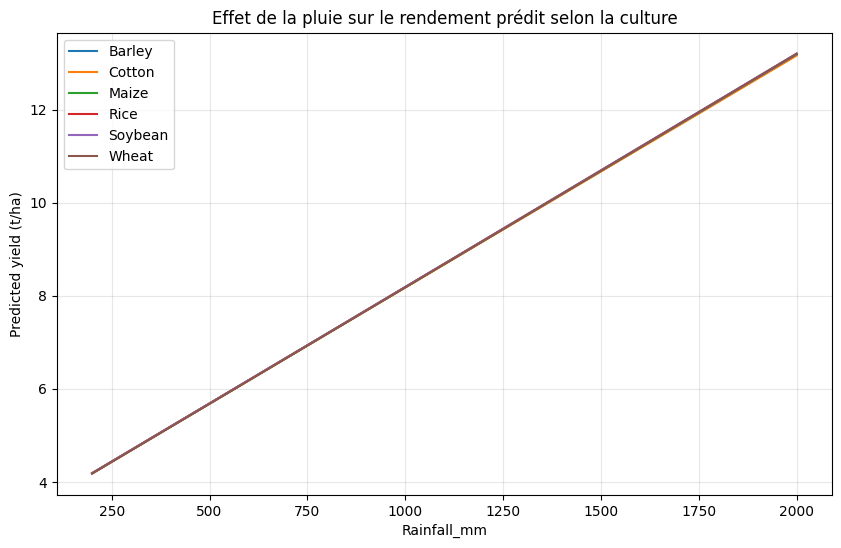

In [82]:
rainfall_grid = np.linspace(200, 2000, 60)

scenario_plot = build_interaction_scenarios(
    rainfall_values=rainfall_grid,
    temperature=24,
    fertilizer_used=True,
    irrigation_used=True,
)

preds = ridge_crop_interactions_pipe.predict(scenario_plot)

plot_df = scenario_plot[["Crop", "Rainfall_mm"]].copy()
plot_df["predicted_yield_t_ha"] = preds

plt.figure(figsize=(10, 6))

for crop_name, group in plot_df.groupby("Crop"):
    group = group.sort_values("Rainfall_mm")
    plt.plot(
        group["Rainfall_mm"],
        group["predicted_yield_t_ha"],
        label=crop_name,
    )

plt.title("Effet de la pluie sur le rendement prédit selon la culture")
plt.xlabel("Rainfall_mm")
plt.ylabel("Predicted yield (t/ha)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

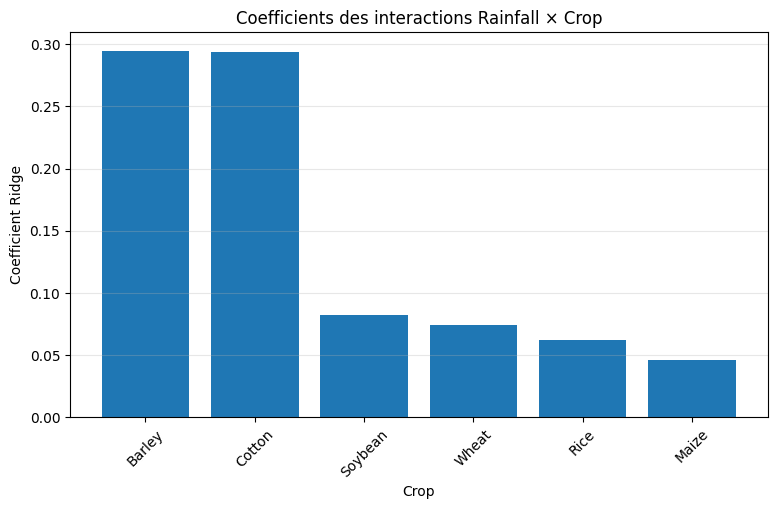

,crop,feature,coefficient,abs_coefficient
3,Barley,num__Rainfall_mm cat__Crop_Barley,0.294914,0.294914
4,Cotton,num__Rainfall_mm cat__Crop_Cotton,0.293414,0.293414
25,Soybean,num__Rainfall_mm cat__Crop_Soybean,0.082155,0.082155
27,Wheat,num__Rainfall_mm cat__Crop_Wheat,0.073901,0.073901
29,Rice,num__Rainfall_mm cat__Crop_Rice,0.061765,0.061765
32,Maize,num__Rainfall_mm cat__Crop_Maize,0.046032,0.046032


In [83]:
rain_crop_coef = coef_df[
    coef_df["feature"].str.contains("Rainfall_mm", na=False)
    & coef_df["feature"].str.contains("Crop", case=False, na=False)
].copy()

# Extraction robuste du nom de culture
rain_crop_coef["crop"] = (
    rain_crop_coef["feature"]
    .str.extract(r"Crop_([^ ]+)", expand=False)
)

# On enlève les lignes mal extraites
rain_crop_coef = rain_crop_coef.dropna(subset=["crop"]).copy()

# Conversion explicite en string
rain_crop_coef["crop"] = rain_crop_coef["crop"].astype(str)

rain_crop_coef = rain_crop_coef.sort_values("coefficient", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(rain_crop_coef["crop"], rain_crop_coef["coefficient"])
plt.title("Coefficients des interactions Rainfall × Crop")
plt.xlabel("Crop")
plt.ylabel("Coefficient Ridge")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

display(rain_crop_coef[["crop", "feature", "coefficient", "abs_coefficient"]])

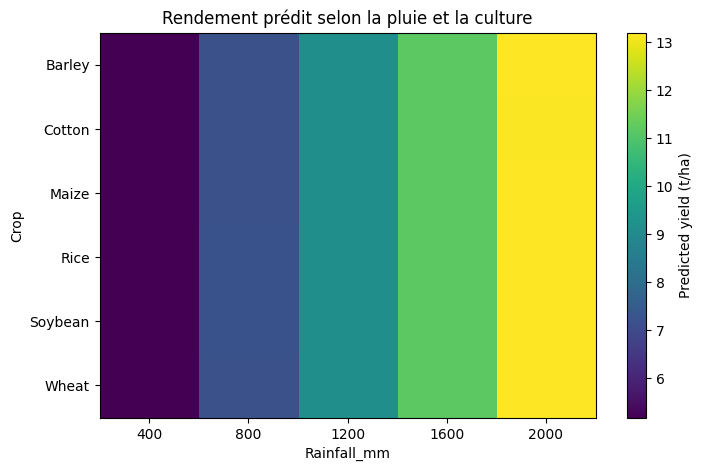

Rainfall_mm,400,800,1200,1600,2000
Crop,,,,,
Barley,5.183367,7.180845,9.178323,11.175802,13.173280
Cotton,5.182724,7.177894,9.173064,11.168234,13.163404
Maize,5.178485,7.178615,9.180909,11.185368,13.191990
Rice,5.184221,7.185616,9.189174,11.194897,13.202783
Soybean,5.183967,7.185807,9.189811,11.195979,13.204311
Wheat,5.176660,7.178795,9.183093,11.189556,13.198182


In [84]:
rainfall_levels = [400, 800, 1200, 1600, 2000]

scenario_heatmap = build_interaction_scenarios(
    rainfall_values=rainfall_levels,
    temperature=24,
    fertilizer_used=True,
    irrigation_used=True,
)

preds_heatmap = ridge_crop_interactions_pipe.predict(scenario_heatmap)

heatmap_df = scenario_heatmap[["Crop", "Rainfall_mm"]].copy()
heatmap_df["predicted_yield_t_ha"] = preds_heatmap

pivot_df = heatmap_df.pivot(
    index="Crop",
    columns="Rainfall_mm",
    values="predicted_yield_t_ha"
)

plt.figure(figsize=(8, 5))
plt.imshow(pivot_df.values, aspect="auto")
plt.colorbar(label="Predicted yield (t/ha)")
plt.xticks(range(len(pivot_df.columns)), pivot_df.columns)
plt.yticks(range(len(pivot_df.index)), pivot_df.index)
plt.title("Rendement prédit selon la pluie et la culture")
plt.xlabel("Rainfall_mm")
plt.ylabel("Crop")
plt.show()

display(pivot_df)

In [85]:
def build_temperature_scenarios(
    temperature_values,
    rainfall=1200,
    fertilizer_used=True,
    irrigation_used=True,
):
    crops = sorted(crop_aux_enriched["Crop"].dropna().astype(str).unique())

    scenario = pd.DataFrame([
        {
            "Crop": crop,
            "Rainfall_mm": rainfall,
            "Temperature_Celsius": temp,
            "Fertilizer_Used": fertilizer_used,
            "Irrigation_Used": irrigation_used,
        }
        for crop in crops
        for temp in temperature_values
    ])

    scenario = scenario.merge(crop_profiles, on="Crop", how="left")

    scenario["rainfall_gap_vs_crop_profile"] = (
        scenario["Rainfall_mm"] - scenario["ext_mean_rainfall_by_crop"]
    )
    scenario["temp_gap_vs_crop_profile"] = (
        scenario["Temperature_Celsius"] - scenario["ext_mean_temp_by_crop"]
    )

    return scenario[crop_interaction_features].copy()

In [86]:


final_crop_variant_name = "crop_enriched_interactions"
final_crop_features = crop_interaction_features
final_crop_cv_summary = ridge_crop_interactions_cv
X_crop_final_full = X_crop_interaction_full

final_crop_pipe = ridge_crop_interactions_pipe

print("Variante retenue :", final_crop_variant_name)
print("Nombre de features :", len(final_crop_features))
print("CV summary :", final_crop_cv_summary)

Variante retenue : crop_enriched_interactions
Nombre de features : 11
CV summary : {'rmse_mean': 0.5001270693083899, 'rmse_std': 0.0005307106532010021, 'mae_mean': 0.3991072673910378, 'mae_std': 0.0005023910197607534, 'r2_mean': 0.9129559594526718, 'r2_std': 0.00025979075524640885}


In [87]:
artifacts_dir = ROOT / "artifacts"
artifacts_dir.mkdir(parents=True, exist_ok=True)

model_1_crop_meta = {
    "model_name": "Ridge",
    "variant_name": final_crop_variant_name,
    "target_name": target_col,
    "target_unit": "t/ha",
    "feature_names": final_crop_features,
    "training_dataset": "crop_aux_enriched",
    "alpha": float(best_interaction_alpha),
    "cv_summary": final_crop_cv_summary,
    "error_margin_t_ha": final_crop_cv_summary["rmse_mean"],
    "supported_crops": sorted(crop_aux_enriched["Crop"].dropna().astype(str).unique().tolist()),
    "crop_support_counts": (
        crop_aux_enriched["Crop"]
        .dropna()
        .astype(str)
        .value_counts()
        .sort_index()
        .to_dict()
    ),
    "interaction_only": True,
    "interaction_degree": 2,
    "preprocessing_note": "Pipeline avec preprocessor + PolynomialFeatures(interaction_only=True, degree=2) + Ridge",
    "note": "Modèle 1 crop final retenu pour l'API, version enrichie avec interactions entre culture et contexte.",
}

joblib.dump(final_crop_pipe, artifacts_dir / "model_1_crop.joblib")

with open(artifacts_dir / "model_1_crop_meta.json", "w", encoding="utf-8") as f:
    json.dump(model_1_crop_meta, f, indent=2, ensure_ascii=False)

print("Artefacts exportés dans :", artifacts_dir)
print("Fichiers : model_1_crop.joblib + model_1_crop_meta.json")

Artefacts exportés dans : C:\Users\thoma\Documents\Openclassroom\Projet-12\artifacts
Fichiers : model_1_crop.joblib + model_1_crop_meta.json


In [88]:
with mlflow.start_run(run_name="model_1_crop_final_enriched_interactions"):
    mlflow.log_param("model_name", "Ridge")
    mlflow.log_param("variant_name", final_crop_variant_name)
    mlflow.log_param("target_name", target_col)
    mlflow.log_param("target_unit", "t/ha")
    mlflow.log_param("training_dataset", "crop_aux_enriched")
    mlflow.log_param("alpha", float(best_interaction_alpha))
    mlflow.log_param("n_features", len(final_crop_features))
    mlflow.log_param("feature_names", ",".join(final_crop_features))
    mlflow.log_param("interaction_only", True)
    mlflow.log_param("interaction_degree", 2)

    for k, v in final_crop_cv_summary.items():
        mlflow.log_metric(k, float(v))

    mlflow.sklearn.log_model(
        sk_model=final_crop_pipe,
        artifact_path="model",
    )

    mlflow.log_artifact(str(artifacts_dir / "model_1_crop_meta.json"))

2026/03/30 15:01:27 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/30 15:01:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/03/30 15:01:31 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


In [89]:
crop_enriched_externalpc_features = [
    "Crop",
    "Rainfall_mm",
    "Temperature_Celsius",
    "Fertilizer_Used",
    "Irrigation_Used",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "rainfall_gap_vs_crop_profile",
    "temp_gap_vs_crop_profile",
    "crop_external_pc1",
    "crop_external_pc2",
]

X_crop_externalpc_sample = sample_df[crop_enriched_externalpc_features].copy()

Xcex_train, Xcex_test, ycex_train, ycex_test = train_test_split(
    X_crop_externalpc_sample,
    y_crop_sample,
    test_size=0.2,
    random_state=SEED
)

ridge_crop_externalpc_sample_pipe = make_pipeline(
    Ridge(alpha=0.1),
    Xcex_train
)

externalpc_sample_result, _ = holdout_metrics(
    ridge_crop_externalpc_sample_pipe,
    Xcex_train,
    Xcex_test,
    ycex_train,
    ycex_test,
    dataset_name="crop_enriched_externalpc",
    model_name="ridge_alpha_0.1_externalpc",
)

display(pd.DataFrame([externalpc_sample_result]))

,dataset,model,rmse,mae,r2
0,crop_enriched_externalpc,ridge_alpha_0.1_externalpc,0.496676,0.396054,0.913955


In [90]:
profile_cols = [
    "Crop",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "crop_external_pc1",
    "crop_external_pc2",
]

crop_profiles = (
    crop_aux_enriched[profile_cols]
    .drop_duplicates(subset=["Crop"])
    .copy()
)

display(crop_profiles.head())

,Crop,ext_mean_temp_by_crop,ext_mean_rainfall_by_crop,ext_mean_pesticides_by_crop,ext_n_obs_by_crop,crop_external_pc1,crop_external_pc2
0,Cotton,NaN,NaN,NaN,NaN,NaN,NaN
1,Rice,20.798107,1221.097204,16443.811451,1502.0,1.438031,1.064397
2,Barley,NaN,NaN,NaN,NaN,NaN,NaN
3,Soybean,18.225843,1135.826087,20043.068696,1242.0,1.604274,-1.392803
4,Wheat,16.394240,906.194475,15075.697000,1810.0,-2.015868,-1.052009


In [91]:
X_crop_externalpc_full = full_df[crop_enriched_externalpc_features].copy()

ridge_crop_externalpc_pipe = make_pipeline(
    Ridge(alpha=0.1),
    X_crop_externalpc_full
)

ridge_crop_externalpc_cv = cross_validate_pipeline(
    pipe=ridge_crop_externalpc_pipe,
    X=X_crop_externalpc_full,
    y=y_crop_full,
    run_name="model_1_crop_enriched_externalpc_ridge_cv",
    stage="crop_variant_cv",
    extra_params={
        "variant": "crop_enriched_externalpc",
        "model_name": "Ridge",
        "alpha": 0.1,
    },
)

display(pd.DataFrame([{"variant": "crop_enriched_externalpc", **ridge_crop_externalpc_cv}]))

,variant,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,crop_enriched_externalpc,0.500121,0.000529,0.399103,0.000501,0.912958,0.00026


In [92]:
crop_interaction_externalpc_features = crop_enriched_externalpc_features.copy()

X_crop_interaction_externalpc_sample = sample_df[crop_interaction_externalpc_features].copy()

Xciex_train, Xciex_test, yciex_train, yciex_test = train_test_split(
    X_crop_interaction_externalpc_sample,
    y_crop_sample,
    test_size=0.2,
    random_state=SEED
)

interaction_externalpc_alphas = [0.1, 1.0, 10.0]
sample_interaction_externalpc_results = []

for alpha in interaction_externalpc_alphas:
    pipe = make_interaction_pipeline(
        Ridge(alpha=alpha),
        Xciex_train,
    )

    result, _ = holdout_metrics(
        pipe,
        Xciex_train,
        Xciex_test,
        yciex_train,
        yciex_test,
        dataset_name=f"crop_enriched_externalpc_interactions_alpha_{alpha}",
        model_name=f"ridge_externalpc_interactions_alpha_{alpha}",
    )
    result["alpha"] = alpha
    sample_interaction_externalpc_results.append(result)

sample_interaction_externalpc_results_df = (
    pd.DataFrame(sample_interaction_externalpc_results)
    .sort_values("rmse")
    .reset_index(drop=True)
)

display(sample_interaction_externalpc_results_df)

,dataset,model,rmse,mae,r2,alpha
0,crop_enriched_externalpc_interactions_alpha_0.1,ridge_externalpc_interactions_alpha_0.1,0.496698,0.39605,0.913947,0.1
1,crop_enriched_externalpc_interactions_alpha_1.0,ridge_externalpc_interactions_alpha_1.0,0.496698,0.39605,0.913947,1.0
2,crop_enriched_externalpc_interactions_alpha_10.0,ridge_externalpc_interactions_alpha_10.0,0.496698,0.39605,0.913947,10.0


In [93]:
best_interaction_externalpc_alpha = float(
    sample_interaction_externalpc_results_df.loc[0, "alpha"]
)

print("Best externalpc interaction alpha:", best_interaction_externalpc_alpha)

X_crop_interaction_externalpc_full = full_df[crop_interaction_externalpc_features].copy()

ridge_crop_interactions_externalpc_pipe = make_interaction_pipeline(
    Ridge(alpha=best_interaction_externalpc_alpha),
    X_crop_interaction_externalpc_full,
)

ridge_crop_interactions_externalpc_cv = cross_validate_pipeline(
    pipe=ridge_crop_interactions_externalpc_pipe,
    X=X_crop_interaction_externalpc_full,
    y=y_crop_full,
    run_name="model_1_crop_enriched_externalpc_interactions_ridge_cv",
    stage="crop_variant_cv",
    extra_params={
        "variant": "crop_enriched_externalpc_interactions",
        "model_name": "Ridge",
        "alpha": best_interaction_externalpc_alpha,
        "interaction_only": True,
        "degree": 2,
    },
)

display(pd.DataFrame([{
    "variant": "crop_enriched_externalpc_interactions",
    **ridge_crop_interactions_externalpc_cv
}]))

Best externalpc interaction alpha: 0.1


,variant,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,crop_enriched_externalpc_interactions,0.500127,0.000531,0.399107,0.000502,0.912956,0.00026


In [94]:
all_ridge_variants_comparison = pd.DataFrame([
    {"variant": "crop_base", **ridge_crop_base_cv},
    {"variant": "crop_enriched", **ridge_crop_enriched_cv},
    {"variant": "crop_enriched_pca_external", **ridge_crop_enriched_pca_cv},
    {"variant": "crop_enriched_context_pca2", **ridge_crop_context_pca2_cv},
    {"variant": "crop_enriched_context_pca3", **ridge_crop_context_pca3_cv},
    {"variant": "crop_enriched_context_pca4", **ridge_crop_context_pca4_cv},
    {"variant": "crop_enriched_interactions", **ridge_crop_interactions_cv},
    {"variant": "crop_enriched_externalpc", **ridge_crop_externalpc_cv},
    {"variant": "crop_enriched_externalpc_interactions", **ridge_crop_interactions_externalpc_cv},
]).sort_values("rmse_mean").reset_index(drop=True)

display(all_ridge_variants_comparison)

,variant,rmse_mean,rmse_std,mae_mean,mae_std,r2_mean,r2_std
0,crop_enriched,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
1,crop_enriched_context_pca4,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
2,crop_enriched_pca_external,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
3,crop_enriched_externalpc,0.500121,0.000529,0.399103,0.000501,0.912958,0.000260
4,crop_base,0.500122,0.000529,0.399103,0.000500,0.912958,0.000259
5,crop_enriched_interactions,0.500127,0.000531,0.399107,0.000502,0.912956,0.000260
6,crop_enriched_externalpc_interactions,0.500127,0.000531,0.399107,0.000502,0.912956,0.000260
7,crop_enriched_context_pca3,0.633228,0.189036,0.498974,0.139440,0.848126,0.100287
8,crop_enriched_context_pca2,1.145831,0.015565,0.841266,0.014040,0.543026,0.012191


In [95]:
ridge_crop_externalpc_pipe.fit(X_crop_externalpc_full, y_crop_full)

ranking_externalpc = crop_ranking_snapshot(
    ridge_crop_externalpc_pipe,
    crop_enriched_externalpc_features,
    "crop_enriched_externalpc",
)

display(ranking_externalpc)

,Crop,predicted_yield_t_ha,dataset_name,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used
0,Rice,9.180668,crop_enriched_externalpc,1200,24,True,True
1,Soybean,9.179211,crop_enriched_externalpc,1200,24,True,True
2,Wheat,9.177161,crop_enriched_externalpc,1200,24,True,True
3,Maize,9.176930,crop_enriched_externalpc,1200,24,True,True
4,Barley,9.174087,crop_enriched_externalpc,1200,24,True,True
5,Cotton,9.173161,crop_enriched_externalpc,1200,24,True,True


In [96]:
ridge_crop_interactions_externalpc_pipe.fit(
    X_crop_interaction_externalpc_full,
    y_crop_full
)

ranking_externalpc_interactions = crop_ranking_snapshot(
    ridge_crop_interactions_externalpc_pipe,
    crop_interaction_externalpc_features,
    "crop_enriched_externalpc_interactions",
)

display(ranking_externalpc_interactions)

,Crop,predicted_yield_t_ha,dataset_name,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used
0,Soybean,9.189811,crop_enriched_externalpc_interactions,1200,24,True,True
1,Rice,9.189174,crop_enriched_externalpc_interactions,1200,24,True,True
2,Wheat,9.183093,crop_enriched_externalpc_interactions,1200,24,True,True
3,Maize,9.180909,crop_enriched_externalpc_interactions,1200,24,True,True
4,Barley,9.178324,crop_enriched_externalpc_interactions,1200,24,True,True
5,Cotton,9.173064,crop_enriched_externalpc_interactions,1200,24,True,True


In [97]:
profile_cols = [
    "Crop",
    "ext_mean_temp_by_crop",
    "ext_mean_rainfall_by_crop",
    "ext_mean_pesticides_by_crop",
    "ext_n_obs_by_crop",
    "crop_external_pc1",
    "crop_external_pc2",
]

crop_profiles = (
    crop_aux_enriched[profile_cols]
    .dropna()
    .drop_duplicates(subset=["Crop"])
    .copy()
)

In [98]:
def build_interaction_scenarios(
    rainfall_values,
    temperature=24,
    fertilizer_used=True,
    irrigation_used=True,
    feature_set=None,
):
    crops = sorted(crop_aux_enriched["Crop"].dropna().astype(str).unique())

    scenario = pd.DataFrame([
        {
            "Crop": crop,
            "Rainfall_mm": rain,
            "Temperature_Celsius": temperature,
            "Fertilizer_Used": fertilizer_used,
            "Irrigation_Used": irrigation_used,
        }
        for crop in crops
        for rain in rainfall_values
    ])

    scenario = scenario.merge(crop_profiles, on="Crop", how="left")

    scenario["rainfall_gap_vs_crop_profile"] = (
        scenario["Rainfall_mm"] - scenario["ext_mean_rainfall_by_crop"]
    )
    scenario["temp_gap_vs_crop_profile"] = (
        scenario["Temperature_Celsius"] - scenario["ext_mean_temp_by_crop"]
    )

    if feature_set is None:
        return scenario.copy()

    return scenario[feature_set].copy()

In [99]:
rainfall_grid = np.linspace(200, 2000, 60)

scenario_base = build_interaction_scenarios(
    rainfall_values=rainfall_grid,
    temperature=24,
    fertilizer_used=True,
    irrigation_used=True,
)

model_scenarios = [
    (
        "crop_enriched_interactions",
        ridge_crop_interactions_pipe,
        crop_interaction_features,
    ),
    (
        "crop_enriched_externalpc",
        ridge_crop_externalpc_pipe,
        crop_enriched_externalpc_features,
    ),
    (
        "crop_enriched_externalpc_interactions",
        ridge_crop_interactions_externalpc_pipe,
        crop_interaction_externalpc_features,
    ),
]

all_plot_dfs = []

for model_name, pipe, feature_cols in model_scenarios:
    scenario_model = scenario_base[feature_cols].copy()
    preds = pipe.predict(scenario_model)

    plot_df = scenario_base[["Crop", "Rainfall_mm"]].copy()
    plot_df["predicted_yield_t_ha"] = preds
    plot_df["model"] = model_name
    all_plot_dfs.append(plot_df)

comparison_plot_df = pd.concat(all_plot_dfs, ignore_index=True)

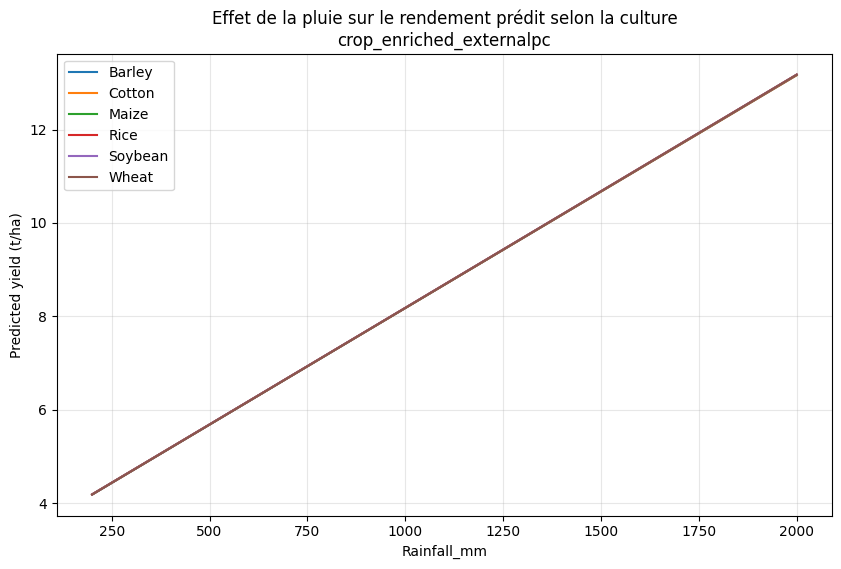

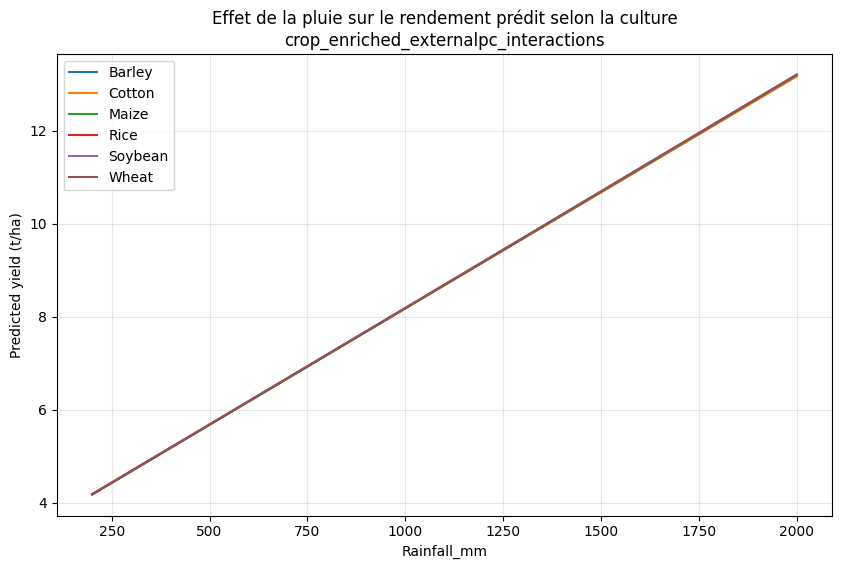

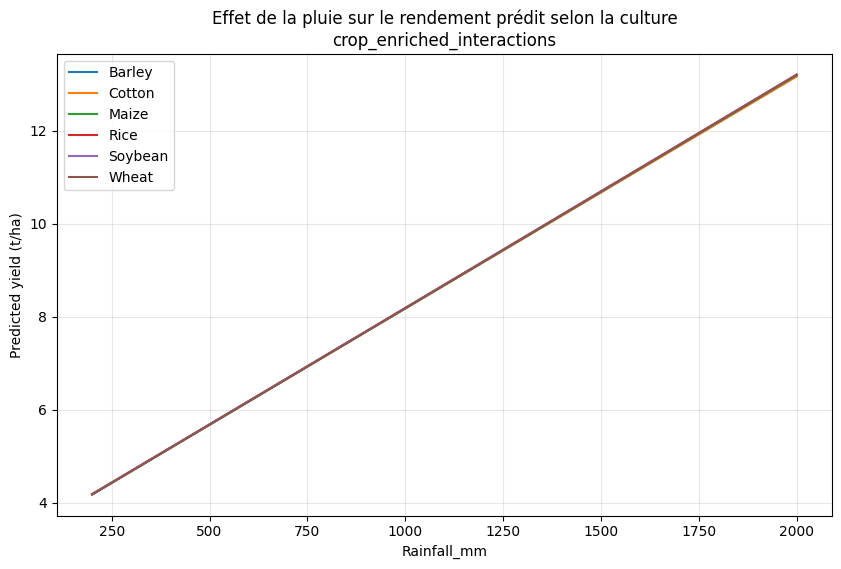

In [100]:
for model_name, group_model in comparison_plot_df.groupby("model"):
    plt.figure(figsize=(10, 6))

    for crop_name, group_crop in group_model.groupby("Crop"):
        group_crop = group_crop.sort_values("Rainfall_mm")
        plt.plot(
            group_crop["Rainfall_mm"],
            group_crop["predicted_yield_t_ha"],
            label=crop_name,
        )

    plt.title(f"Effet de la pluie sur le rendement prédit selon la culture\n{model_name}")
    plt.xlabel("Rainfall_mm")
    plt.ylabel("Predicted yield (t/ha)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [101]:
discrimination_summary = (
    comparison_plot_df
    .groupby(["model", "Rainfall_mm"])["predicted_yield_t_ha"]
    .agg(["min", "max", "mean", "std"])
    .reset_index()
)

discrimination_summary["range_between_crops"] = (
    discrimination_summary["max"] - discrimination_summary["min"]
)

display(discrimination_summary.head())

,model,Rainfall_mm,min,max,mean,std,range_between_crops
0,crop_enriched_externalpc,200.000000,4.179466,4.184596,4.182063,0.002133,0.005130
1,crop_enriched_externalpc,230.508475,4.331931,4.336818,4.334447,0.002040,0.004887
2,crop_enriched_externalpc,261.016949,4.484396,4.489039,4.486831,0.001951,0.004644
3,crop_enriched_externalpc,291.525424,4.636861,4.641261,4.639215,0.001866,0.004400
4,crop_enriched_externalpc,322.033898,4.789326,4.793483,4.791599,0.001786,0.004157


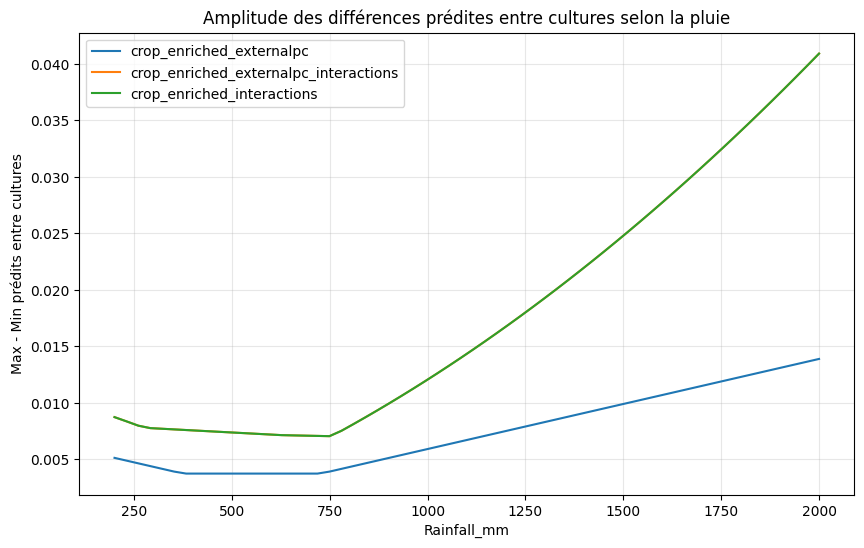

In [102]:
plt.figure(figsize=(10, 6))

for model_name, group in discrimination_summary.groupby("model"):
    group = group.sort_values("Rainfall_mm")
    plt.plot(
        group["Rainfall_mm"],
        group["range_between_crops"],
        label=model_name,
    )

plt.title("Amplitude des différences prédites entre cultures selon la pluie")
plt.xlabel("Rainfall_mm")
plt.ylabel("Max - Min prédits entre cultures")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Conclusion opérationnelle

### Modèles conservés
- **`model_1_general`** : baseline générale, utile comme référence interne ;
- **`model_1_crop`** : vrai modèle métier final pour l'API.

### Blocs retirés du notebook principal
- feature engineering non retenu ;
- outliers / winsorisation non retenus ;
- benchmarks intermédiaires redondants.

### Étape suivante
Utiliser :
- `model_1_crop.*`
- `model_1_general.*`
- `model_2_recommendation.*`

pour construire l'API FastAPI et ses règles métier de routage / fiabilité.